# 48 - Milestone Project: Teaching a Network to Add

**Section:** FNN Milestone Projects | **Prereqs:** `FNN Milestone Projects/FNN_HeartDisease.ipynb` | **Next:** `FNN Milestone Projects/ProjectMissingDataInterPolationipynb`

Two inputs, one output, and the target is `a + b`. Trivially easy for a
calculator, genuinely instructive for a network - it can only learn addition
*over the range it was trained on*. Test it on larger numbers and it fails, which
is the clearest possible demonstration that these models interpolate rather than
reason.

**New tools in this notebook**
- **`HuberLoss`** - quadratic near zero, linear far from it. Less sensitive to
  outliers than MSE, since a single terrible prediction cannot dominate the
  gradient.
- **`r2_score`** - the fraction of variance explained. 1.0 is perfect, 0 means
  'no better than predicting the mean'. The standard regression score, unlike raw
  MSE it is scale-free.
- **Scaling the target too**, with a second scaler, and `inverse_transform` to
  read predictions back in the original units. Necessary when the target's range
  is far from 1; essential to remember to invert before reporting.

**Also here:** L2 (`weight_decay`) and hand-written L1 in the same loss, which is
elastic-net regularisation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# A CSV of (a, b, a+b) triples.
data = pd.read_csv('/content/data.csv')
data.head()

,Value1,Value2,Result
0,-145,822,677
1,902,-988,-86
2,-392,111,-281
3,464,389,853
4,882,-700,182


In [ ]:
data.shape

(4004, 3)

In [ ]:
# Missing-value check before anything else.
data.isna().sum()

,0
Value1,0
Value2,0
Result,0


In [ ]:
data.describe()

,Value1,Value2,Result
count,4004.000000,4004.000000,4004.000000
mean,-2.148352,2.166583,0.018232
std,325.436665,318.562966,449.914544
min,-999.000000,-998.000000,-1915.000000
25%,-79.000000,-78.250000,-90.250000
50%,-1.500000,-2.000000,0.000000
75%,76.000000,80.000000,93.000000
max,1000.000000,999.000000,1976.000000


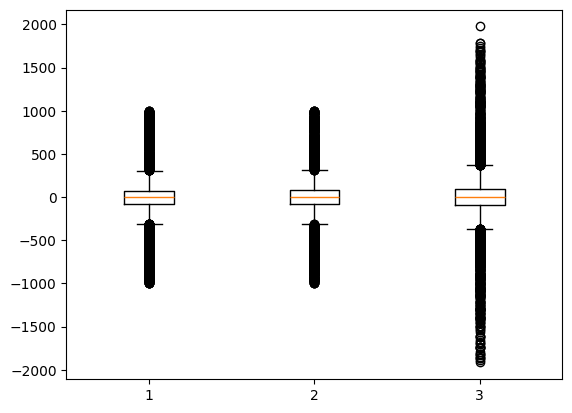

In [ ]:
# Box plot of the raw columns.
plt.boxplot(data);

In [ ]:
# Features = the two addends, target = the sum, reshaped to (N,1) to match the
# model's output.
train = data.drop(columns=['Result'])
target = data['Result']

train = torch.tensor(train.to_numpy(), dtype=torch.float, device='cuda')
target = torch.tensor(target, dtype=torch.float, device='cuda')

target = target.view(target.shape[0],1)

target.shape


torch.Size([4004, 1])

In [ ]:
target.shape

torch.Size([4004, 1])

In [ ]:
# Three-way split (80/10/10), then TWO scalers: one for the features and one
# for the target.
# Both are fit on train only and applied to val and test. The label scaler must
# be kept - predictions come back in scaled units and need inverse_transform
# before they mean anything.
train_data,test_data, train_label, test_label = train_test_split(train, target, test_size=0.2)
val_data, test_data, val_label , test_label  = train_test_split(test_data, test_label, test_size=0.5)

scaler_data = StandardScaler()
scaler_label = StandardScaler()

# Scale the training data and labels
train_data = torch.tensor(scaler_data.fit_transform(train_data.cpu()), dtype=torch.float, device='cuda')
train_label = torch.tensor(scaler_label.fit_transform(train_label.cpu().reshape(-1, 1)), dtype=torch.float, device='cuda')

# Scale the validation data and labels
val_data = torch.tensor(scaler_data.transform(val_data.cpu()), dtype=torch.float, device='cuda')
val_label = torch.tensor(scaler_label.transform(val_label.cpu().reshape(-1, 1)), dtype=torch.float, device='cuda')

# Scale the test data and labels
test_data = torch.tensor(scaler_data.transform(test_data.cpu()), dtype=torch.float, device='cuda')
test_label = torch.tensor(scaler_label.transform(test_label.cpu().reshape(-1, 1)), dtype=torch.float, device='cuda')

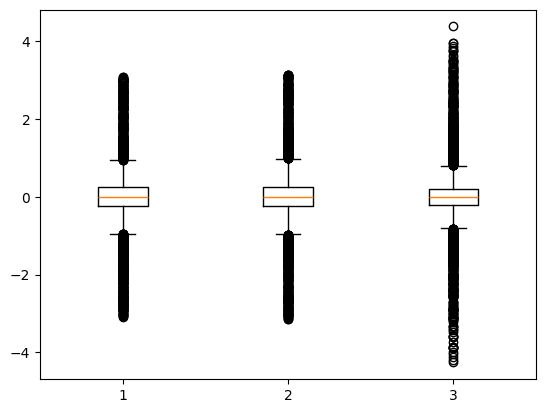

In [ ]:
# Box plot of the scaled features and target together - all comparable now.
plt.boxplot(torch.concatenate([train_data.detach().cpu(), train_label.detach().cpu()],axis=1).detach());

In [ ]:

train_tensor = TensorDataset(train_data, train_label)
val_tensor = TensorDataset(val_data, val_label)

bs = 128
train_loader = DataLoader(train_tensor, shuffle=True, batch_size=bs, drop_last=True)
val_loader = DataLoader(val_tensor, shuffle=True, batch_size=val_tensor.tensors[0].shape[0])


In [ ]:
# 2 -> 128 -> 64 -> 64 -> 16 -> 1 with batch norm throughout.
# Wildly oversized for addition, which is the point: even so, it will only learn
# the mapping over the range of values it was shown.
# Dropout is applied after the two widest hidden layers - a layer declared in
# __init__ but never called in forward does nothing at all.
class machine(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(2,128)
    self.bnorm0 = nn.BatchNorm1d(128)

    self.fc1 = nn.Linear(128,64)
    self.bnorm1 = nn.BatchNorm1d(64)

    self.fc2 = nn.Linear(64,64)
    self.bnorm2 = nn.BatchNorm1d(64)

    self.fc3 = nn.Linear(64,16)
    self.bnorm3 = nn.BatchNorm1d(16)

    self.output_layer = nn.Linear(16,1)

    self.dropout_layer = nn.Dropout(p=0.5)


  def forward(self,x):

    x = F.relu(self.bnorm0(self.input_layer(x)))
    x = self.dropout_layer(x)
    x = F.relu(self.bnorm1(self.fc1(x)))
    x = self.dropout_layer(x)
    x = F.relu(self.bnorm2(self.fc2(x)))
    x = F.relu(self.bnorm3(self.fc3(x)))

    x = self.output_layer(x)

    return (x)

In [ ]:
# HuberLoss plus BOTH regularisers: weight_decay=1e-4 (L2, via the optimizer)
# and a hand-computed L1 term added to the loss. Using both together is
# elastic-net regularisation.
# The L1 term is recomputed every batch because the weights change every batch.
# Note val_loss is assigned a fresh nn.HuberLoss() object inside the loop rather
# than a computed value - it is used correctly in the print, but the name is
# misleading.
def train_model():

  model = machine().to('cuda')

  lossFunc = nn.HuberLoss()
  epochs = 50

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=0.0001)

  R2 = []
  losses = []

  num_weights = 0
  L1_lambda = 0.0001

  for name,elems in model.named_parameters():
   if "bias" not in name:
    num_weights += elems.numel()

  for epoch in range(epochs):

   model.train()

   batch_loss = []
   batch_acc = []

   for x,y in train_loader:

     yhat = model(x)

     loss = lossFunc(yhat, y)

     L1_term = torch.tensor(0.,requires_grad=True)

     for name, elems in model.named_parameters():
      if 'bias' not in name :
        L1_term = L1_term + torch.sum(torch.abs(elems))

     loss = loss + L1_lambda * (L1_term) # TODO : Using average here for now, will check before shiping

     batch_loss.append(loss.item())

     optimizer.zero_grad()
     loss.backward()
     optimizer.step()

   losses.append(np.mean(batch_loss))

   model.eval()
   with torch.no_grad():
    X,Y = next(iter(val_loader))
    R2.append(r2_score(model(X).detach().cpu(), Y.detach().cpu()))
    val_loss = nn.HuberLoss()


   if epoch % 10 == 0 or epochs - 1 == epoch:
    print(f'Epoch {epoch} | Loss : {losses[epoch]} | R2 {R2[epoch]}| Val Loss : {val_loss(model(X).detach().cpu(), Y.detach().cpu())}')

  return losses, R2, model


In [ ]:
losses, R2, model = train_model()

Epoch 0 | Loss : 0.3629009425640106 | R2 -14.915649540462814| Val Loss : 0.29817822575569153
Epoch 10 | Loss : 0.12480628192424774 | R2 0.9774328334381366| Val Loss : 0.010220596566796303
Epoch 20 | Loss : 0.113119355738163 | R2 0.9956106038712219| Val Loss : 0.0021720610093325377
Epoch 30 | Loss : 0.10653734862804413 | R2 0.996350761647949| Val Loss : 0.0017121911514550447
Epoch 40 | Loss : 0.10573992252349854 | R2 0.9912597141741982| Val Loss : 0.0038881280925124884
Epoch 49 | Loss : 0.10358327120542526 | R2 0.997227001921427| Val Loss : 0.001358928857371211


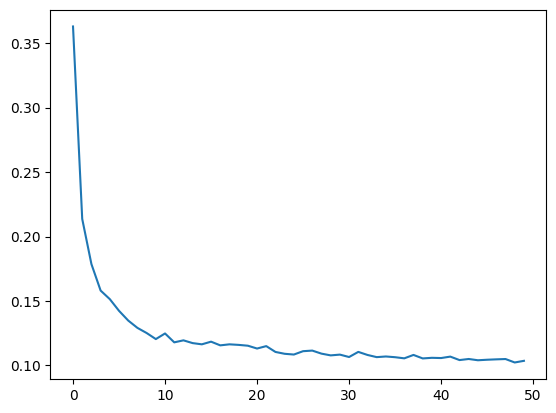

In [ ]:
# Training loss.
plt.plot(losses);

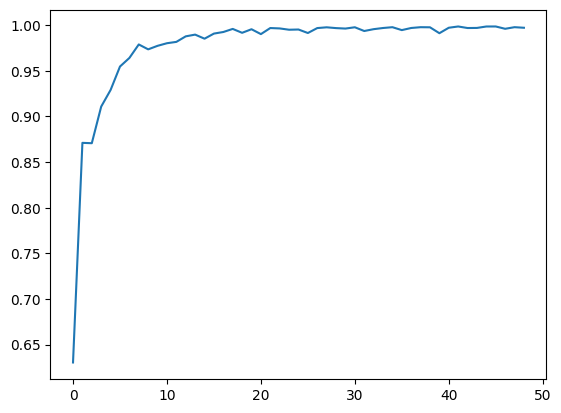

In [ ]:
# R2 on the validation set per epoch, skipping the first (untrained) point which
# is hugely negative and would flatten the whole plot.
plt.plot(R2[1:]);

In [ ]:
# Test evaluation, with the crucial step: inverse_transform BOTH predictions and
# labels before computing the error, so the numbers are in the original units.
# Reporting a scaled MSE is a common and confusing mistake.
# Now testing the data:

preds = model(test_data)

preds_np = preds.detach().cpu().numpy()
labels_np = test_label.detach().cpu().numpy()

preds_inv = scaler_label.inverse_transform(preds_np)
labels_inv = scaler_label.inverse_transform(labels_np)

val_loss = nn.MSELoss()
loss = val_loss(torch.tensor(preds_inv), torch.tensor(labels_inv))

# Compute R2
R2_test = r2_score(labels_inv, preds_inv)

In [ ]:
# Final test MSE and R2. R2 near 1.0 means the model learned addition over the
# training range. Feed it inputs far outside that range and it will fail - it
# learned a surface that fits, not the rule.
print(f'Test Eval: \nMSE {np.sqrt(loss.item())} | R2 {R2_test}')

Test Eval: 
RMSE 25.297983636531562 | R2 0.9967277646064758


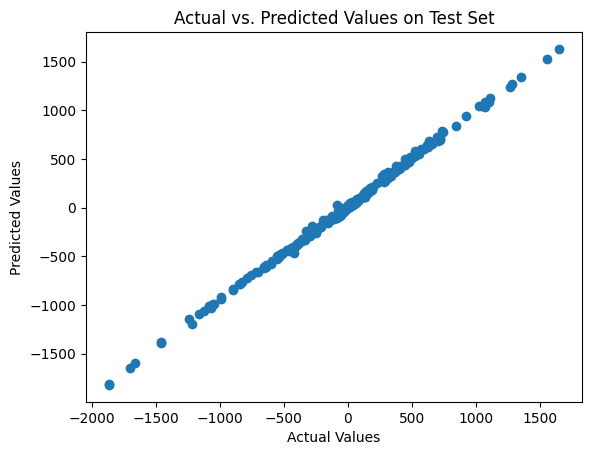

In [ ]:
# Predicted vs actual. A perfect model lies exactly on the diagonal.
plt.scatter(scaler_label.inverse_transform(test_label.detach().cpu()), scaler_label.inverse_transform(preds.detach().cpu()))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values on Test Set");


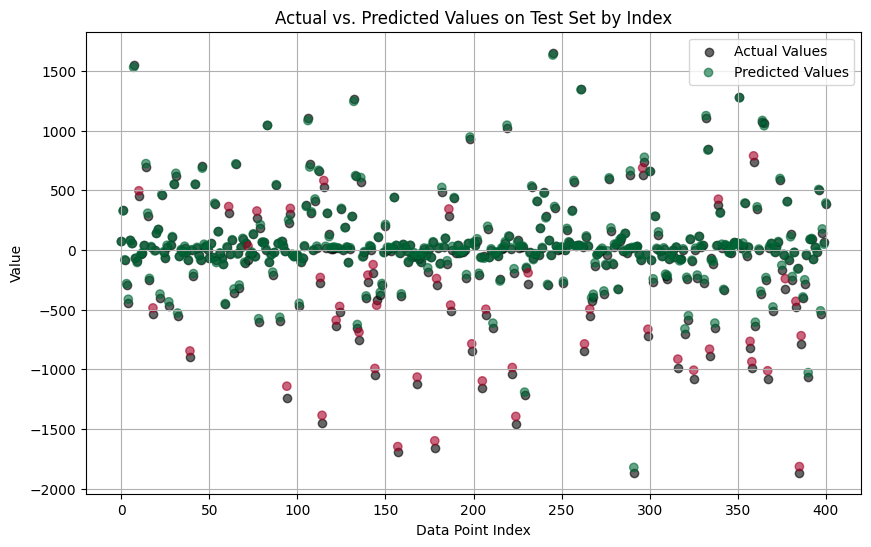

In [ ]:
# The same, per data point, coloured by whether the error is within a threshold.
# Useful for spotting whether errors are random or concentrated in one region of
# the input range - the latter usually means the model never saw that region.
# Calculate the difference between actual and predicted values
difference = torch.abs(test_label.detach().cpu() - preds.detach().cpu())

# Define a threshold for considering a prediction "wrong"
threshold = 0.1 # You can adjust this threshold based on your needs

plt.figure(figsize=(10, 6))

# Plot actual values in black
plt.scatter(range(test_label.shape[0]), labels_inv, color='k', label='Actual Values', alpha=0.6)

# Plot predicted values, colored based on the difference
plt.scatter(range(preds.shape[0]), preds_inv, c=(difference <= threshold), cmap='RdYlGn', label='Predicted Values', alpha=0.6)

plt.xlabel("Data Point Index")
plt.ylabel("Value")
plt.title("Actual vs. Predicted Values on Test Set by Index")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Correlation on the original scale, as a final single-number summary.
correlation_original_scale = np.corrcoef(labels_inv.flatten(), preds_inv.flatten())

print(f'Correlation coefficient on original scale: {correlation_original_scale[0][1]}')

Correlation coefficient on original scale: 0.9990296025820636
